# Prophet

### 1. Уточнение Параметров Модели

Так как у вас нет тренда в данных, использование `growth='linear'` может быть нецелесообразным. Вместо этого мы можем использовать `growth='flat'`, который предполагает отсутствие тренда.

Касательно режима сезонности, аддитивная сезонность (`seasonality_mode='additive'`) подходит, когда сезонные эффекты имеют постоянный размер вне зависимости от уровня временного ряда. Если же сезонные эффекты зависят от уровня временного ряда, можно использовать мультипликативную сезонность (`seasonality_mode='multiplicative'`). В вашем случае, если количество выпуска сертификатов на выходных всегда снижается на примерно одно и то же количество, аддитивная сезонность подходит.

### 2. Разделение Данных на Train и Test

Разделим данные на обучающую (train) и тестовую (test) выборки. Обучающая выборка будет состоять из первых 209 дней, а тестовая — из оставшихся.

### 3. Построение Модели и Расчет Метрик

Мы будем использовать метрики RMSE (Root Mean Square Error) и MAE (Mean Absolute Error) для оценки качества модели.

### 4. Построение Графиков

Построим графики с фактическими данными, прогнозами и доверительными интервалами.

### 5. Кросс-Валидация

Используем кросс-валидацию для оценки стабильности модели.

Ниже представлен полный код для выполнения всех этих шагов:

```python
import pandas as pd
import numpy as np
from fbprophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from fbprophet.diagnostics import cross_validation, performance_metrics

# Предположим, что df - ваш DataFrame с данными
# Пример данных:
# df = pd.DataFrame({
#     'date': pd.date_range(start='2024-10-01', periods=230),
#     'certificates': [np.random.randint(10, 100) for _ in range(230)],
#     'holidays': [0] * 230,  # Пример данных о праздниках
#     'weekend': [0 if d.weekday() < 5 else 1 for d in pd.date_range(start='2024-10-01', periods=230)],  # Пример данных о выходных
#     'working_saturdays': [0] * 230,  # Пример данных о рабочих субботах
#     'registration_centers': [np.random.randint(5, 20) for _ in range(230)]  # Пример данных о регистрационных центрах
# })

# Подготовка данных
df_prophet = df[['date', 'certificates']].copy()
df_prophet.columns = ['ds', 'y']

# Добавление дополнительных факторов
df_prophet['holidays'] = df['holidays']
df_prophet['weekend'] = df['weekend']
df_prophet['working_saturdays'] = df['working_saturdays']
df_prophet['registration_centers_lag_1'] = df['registration_centers'].shift(1)
df_prophet['lag_1'] = df['lag_1']
df_prophet['lag_2'] = df['lag_2']
df_prophet['lag_3'] = df['lag_3']
df_prophet['lag_4'] = df['lag_4']
df_prophet['rolling_mean_3'] = df['rolling_mean_3']
df_prophet['rolling_mean_7'] = df['rolling_mean_7']
df_prophet['exp_smooth'] = df['exp_smooth']
df_prophet['diff_1'] = df['diff_1']
df_prophet['diff_2'] = df['diff_2']

# Разделение данных на train и test
train_size = 209
train = df_prophet.iloc[:train_size]
test = df_prophet.iloc[train_size:]

# Создание модели Prophet
model = Prophet(growth='flat', yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False, seasonality_mode='additive')

# Добавление дополнительных регрессоров
model.add_regressor('holidays')
model.add_regressor('weekend')
model.add_regressor('working_saturdays')
model.add_regressor('registration_centers_lag_1')
model.add_regressor('lag_1')
model.add_regressor('lag_2')
model.add_regressor('lag_3')
model.add_regressor('lag_4')
model.add_regressor('rolling_mean_3')
model.add_regressor('rolling_mean_7')
model.add_regressor('exp_smooth')
model.add_regressor('diff_1')
model.add_regressor('diff_2')

# Обучение модели
model.fit(train)

# Создание фрейма данных для предсказания
future = model.make_future_dataframe(periods=len(test))
future['holidays'] = df_prophet['holidays'].reindex(future.index, method='ffill')
future['weekend'] = df_prophet['weekend'].reindex(future.index, method='ffill')
future['working_saturdays'] = df_prophet['working_saturdays'].reindex(future.index, method='ffill')
future['registration_centers_lag_1'] = df_prophet['registration_centers_lag_1'].reindex(future.index, method='ffill')
future['lag_1'] = df_prophet['lag_1'].reindex(future.index, method='ffill')
future['lag_2'] = df_prophet['lag_2'].reindex(future.index, method='ffill')
future['lag_3'] = df_prophet['lag_3'].reindex(future.index, method='ffill')
future['lag_4'] = df_prophet['lag_4'].reindex(future.index, method='ffill')
future['rolling_mean_3'] = df_prophet['rolling_mean_3'].reindex(future.index, method='ffill')
future['rolling_mean_7'] = df_prophet['rolling_mean_7'].reindex(future.index, method='ffill')
future['exp_smooth'] = df_prophet['exp_smooth'].reindex(future.index, method='ffill')
future['diff_1'] = df_prophet['diff_1'].reindex(future.index, method='ffill')
future['diff_2'] = df_prophet['diff_2'].reindex(future.index, method='ffill')

# Предсказание
forecast = model.predict(future)

# Извлечение предсказаний для тестовой выборки
y_true = test['y'].values
y_pred = forecast['yhat'].iloc[-len(test):].values

# Расчет метрик
rmse_train = np.sqrt(mean_squared_error(train['y'], model.predict(train)['yhat']))
mae_train = mean_absolute_error(train['y'], model.predict(train)['yhat'])
rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
mae_test = mean_absolute_error(y_true, y_pred)

print(f"RMSE на train: {rmse_train}")
print(f"MAE на train: {mae_train}")
print(f"RMSE на test: {rmse_test}")
print(f"MAE на test: {mae_test}")

# Построение графика с фактическими данными, прогнозами и доверительными интервалами
plt.figure(figsize=(14, 7))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2)
plt.legend()
plt.title('Прогноз выпуска сертификатов')
plt.show()

# Кросс-валидация
df_cv = cross_validation(model, initial='209 days', period='30 days', horizon='30 days')
df_p = performance_metrics(df_cv)
print(df_p.head())

# Построение графика кросс-валидации
from fbprophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.show()
```

### Пояснения

1. **Разделение данных на train и test**:
   - Обучающая выборка (`train`) состоит из первых 209 дней.
   - Тестовая выборка (`test`) состоит из оставшихся дней.

2. **Построение модели Prophet**:
   - Используем `growth='flat'` для отсутствия тренда.
   - Добавляем дополнительные регрессоры с помощью метода `add_regressor`.

3. **Расчет метрик**:
   - Используем RMSE и MAE для оценки качества модели на обучающей и тестовой выборках.

4. **Построение графиков**:
   - На графике показаны фактические данные, прогнозы и доверительные интервалы.

5. **Кросс-валидация**:
   - Используем функцию `cross_validation` для оценки стабильности модели.
   - Построим график RMSE для кросс-валидации.

Если у вас есть дополнительные данные или специфические требования, пожалуйста, укажите, и я корректирую код соответственно.

▌1. Генерация дополнительных факторов

С учетом вашего описания, вы уже проделали большую работу по генерации признаков. Вот что еще можно добавить:

▌Возможные дополнительные факторы:

1. Rolling statistics (скользящие статистики): 
  - Среднее, медиана, стандартное отклонение по количеству сертификатов за последние n дней (например, 3, 7, 14).
  - Это часто помогает моделям учитывать локальные "инерционные" эффекты.

2. Lag-фичи для регистрационных центров: 
  - Помимо лага = 1, можно рассмотреть лаги = 2, 3, а также скользящие средние по центрам.

3. Флаги начала/конца месяца: 
  - Иногда в начале или конце месяца активность меняется.

4. Период отпусков: 
  - Если есть ярко выраженные “мертвые сезоны” (например, новогодние каникулы, майские праздники) — можно добавить бинарный индикатор этих периодов.

5. Динамика по неделям: 
  - Например, порядковый номер недели в году — иногда активность зависит от недели.

6. Погода/Внешние события: 
  - Если есть подозрение, что внешние события влияют, можно добавить соответствующие фичи.

Вопросы для уточнения:
- Есть ли доступ к информации о количестве заявок на выпуск сертификатов (а не только о выпущенных)?
- Есть ли информация о внешних событиях, которые могли бы влиять на динамику?
- Нужно ли учитывать праздничные переносы (если выходной перенесён на будний день)?

---

▌2. Модель Facebook Prophet — описание и гиперпараметры

Prophet — мощный инструмент для моделирования временных рядов с выраженной сезонностью и праздниками. 
Основные компоненты модели:
- Trend (тренд) — общий уровень ряда (у вас отсутствует).
- Seasonality (сезонность) — регулярные колебания (например, недельная).
- Holidays (праздники).
- Регрессоры (дополнительные факторы).

▌Важные гиперпараметры Prophet:

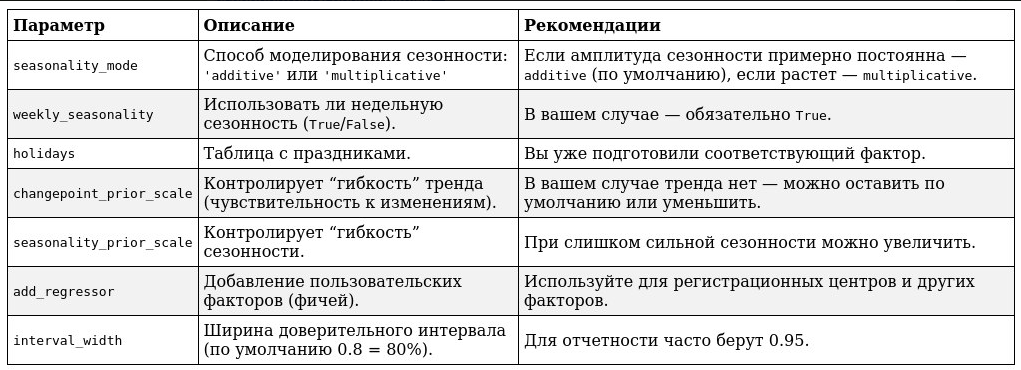

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt

# 1. Загрузка данных (замените на ваш путь)
df = pd.read_csv('certificates_daily.csv')  # Ожидается, что есть столбцы: 'date', 'count', 'centers', 'holiday_flag', 'work_saturday'
df['date'] = pd.to_datetime(df['date'])

# 2. Генерация дополнительных фичей
# Скользящее среднее за 7 дней
df['count_roll7'] = df['count'].rolling(window=7, min_periods=1).mean()
# Скользящее среднее по центрам за 3 дня
df['centers_roll3'] = df['centers'].rolling(window=3, min_periods=1).mean()
# Порядковый номер недели
df['week_number'] = df['date'].dt.isocalendar().week
# Признак "начало месяца"
df['start_month'] = (df['date'].dt.day <= 3).astype(int)
# День недели (sin, cos)
df['dow'] = df['date'].dt.weekday
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

# 3. Подготовка данных для Prophet
prophet_df = df.rename(columns={'date': 'ds', 'count': 'y'})

# 4. Разделение на train и test
train = prophet_df.iloc[:209]
test = prophet_df.iloc[209:]

# 5. Определяем праздники для Prophet
holidays = pd.DataFrame({
    'holiday': 'holiday_flag',
    'ds': prophet_df[prophet_df['holiday_flag'] == 1]['ds'],
    'lower_window': 0,
    'upper_window': 0,
})

# 6. Инициализация Prophet
m = Prophet(
    seasonality_mode='additive',  # Можно попробовать 'multiplicative'
    weekly_seasonality=True,
    yearly_seasonality=False,
    holidays=holidays,
    interval_width=0.95,
    changepoint_prior_scale=0.01,  # Тренда нет — делаем менее гибким
    seasonality_prior_scale=10     # Усиливаем влияние сезонности
)

# 7. Добавление регрессоров
m.add_regressor('centers', mode='additive')
m.add_regressor('work_saturday', mode='additive')
m.add_regressor('count_roll7', mode='additive')
m.add_regressor('centers_roll3', mode='additive')
m.add_regressor('start_month', mode='additive')
m.add_regressor('dow_sin', mode='additive')
m.add_regressor('dow_cos', mode='additive')

# 8. Обучение
cols = ['ds', 'y', 'centers', 'work_saturday', 'count_roll7', 'centers_roll3', 'start_month', 'dow_sin', 'dow_cos']
m.fit(train[cols])

# 9. Прогнозирование
future = prophet_df[cols].copy()
forecast = m.predict(future)

# 10. Оценка метрик
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Train
train_forecast = forecast.iloc[:209]
mae_train, rmse_train = get_metrics(train['y'], train_forecast['yhat'])

# Test
test_forecast = forecast.iloc[209:]
mae_test, rmse_test = get_metrics(test['y'], test_forecast['yhat'])

print(f"Train MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}")
print(f"Test  MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")

# 11. Визуализация
plt.figure(figsize=(16,6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='Факт', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Прогноз', color='blue')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='blue', alpha=0.2, label='Доверительный интервал')
plt.axvline(x=prophet_df['ds'].iloc[209], color='red', linestyle='--', label='Начало теста')
plt.legend()
plt.title('Прогноз выпуска сертификатов')
plt.xlabel('Дата')
plt.ylabel('Количество сертификатов')
plt.show()

# 12. Кросс-валидация Prophet
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(m, initial='150 days', period='15 days', horizon='20 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse', 'coverage']])

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

# 1. Определяем дату последнего наблюдения
last_date = prophet_df['ds'].max()
future_dates = pd.date_range(last_date + timedelta(days=1), periods=28)

# 2. Формируем future DataFrame с нужными регрессорами
future = pd.DataFrame({'ds': future_dates})

# Дни недели
future['dow'] = future['ds'].dt.weekday
future['dow_sin'] = np.sin(2 * np.pi * future['dow'] / 7)
future['dow_cos'] = np.cos(2 * np.pi * future['dow'] / 7)

# Признак "начало месяца"
future['start_month'] = (future['ds'].dt.day <= 3).astype(int)

# Порядковый номер недели
future['week_number'] = future['ds'].dt.isocalendar().week

# --- ВАЖНО! ---
# Для регрессоров, которые нельзя предсказать (например, centers, work_saturday, count_roll7, centers_roll3), 
# нужно заранее подготовить значения.
# Можно использовать последние известные значения или сделать свой прогноз/экспертную оценку.

# Пример: заполняем будущие значения центров и скользящих средних последним известным значением
last_centers = prophet_df['centers'].iloc[-1]
future['centers'] = last_centers

last_work_saturday = 0  # Обычно суббота — выходной, если не планируется рабочая
future['work_saturday'] = np.where(future['ds'].dt.weekday == 5, last_work_saturday, 0)

last_count_roll7 = prophet_df['count_roll7'].iloc[-1]
future['count_roll7'] = last_count_roll7

last_centers_roll3 = prophet_df['centers_roll3'].iloc[-1]
future['centers_roll3'] = last_centers_roll3

# Если у вас есть календарь праздников на будущий период — добавьте holiday_flag, иначе выставьте 0
future['holiday_flag'] = 0

# 3. Объединяем future с исходным prophet_df для прогноза "от сегодня и дальше"
future_full = pd.concat([prophet_df[cols], future[cols[1:]]], ignore_index=True)

# 4. Строим прогноз
forecast_future = m.predict(future_full)

# 5. Визуализация только будущих дат
forecast_4w = forecast_future.iloc[-28:]

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(forecast_4w['ds'], forecast_4w['yhat'], label='Прогноз')
plt.fill_between(forecast_4w['ds'], forecast_4w['yhat_lower'], forecast_4w['yhat_upper'], color='blue', alpha=0.2, label='Доверительный интервал')
plt.title('Прогноз выпуска сертификатов на 4 недели вперед')
plt.xlabel('Дата')
plt.ylabel('Количество сертификатов')
plt.legend()
plt.grid()
plt.show()

# Catboost

### **Подготовка данных**
1. **Добавление признаков**:
   - День недели (как категориальный признак).
   - Праздники, выходные и рабочие субботы.
   - Лаги (1, 2, 3, 4).
   - Скользящие средние (3-дневная и 7-дневная).
   - Экспоненциальное сглаживание.
   - Разницы (diff_1, diff_2).
   - Информация о регистрационных центрах с лагом 1.

2. **Разделение на train/test**:
   - Train: первые 209 дней.
   - Test: оставшиеся 21 день (230 - 209 = 21).

---

### **Код для модели CatBoost**
```python
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# Пример данных (замените на свои)
# df = pd.DataFrame({
#     'date': pd.date_range(start='2024-10-01', periods=230),
#     'certificates': [np.random.randint(10, 100) for _ in range(230)],
#     'holidays': [0] * 230,  # 1 - праздник, 0 - нет
#     'weekend': [0 if d.weekday() < 5 else 1 for d in pd.date_range(start='2024-10-01', periods=230)],
#     'working_saturdays': [0] * 230,  # 1 - рабочая суббота, 0 - нет
#     'registration_centers': [np.random.randint(5, 20) for _ in range(230)]
# })

# Генерация признаков
df['day_of_week'] = df['date'].dt.dayofweek  # 0 (Пн) - 6 (Вс)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Лаги
for lag in [1, 2, 3, 4]:
    df[f'lag_{lag}'] = df['certificates'].shift(lag)

# Скользящие средние
df['rolling_mean_3'] = df['certificates'].rolling(window=3).mean()
df['rolling_mean_7'] = df['certificates'].rolling(window=7).mean()

# Экспоненциальное сглаживание
df['exp_smooth'] = df['certificates'].ewm(span=3, adjust=False).mean()

# Разницы
df['diff_1'] = df['certificates'].diff(1)
df['diff_2'] = df['certificates'].diff(2)

# Лаг регистрационных центров
df['registration_centers_lag_1'] = df['registration_centers'].shift(1)

# Удаление пропущенных значений из-за лагов
df = df.dropna()

# Разделение на train и test
train_size = 209
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Формирование признаков и целевого признака
features = [
    'holidays',
    'weekend',
    'working_saturdays',
    'registration_centers_lag_1',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'rolling_mean_3', 'rolling_mean_7',
    'exp_smooth',
    'diff_1', 'diff_2',
    'day_of_week_sin', 'day_of_week_cos'
]

X_train = train_df[features]
y_train = train_df['certificates']

X_test = test_df[features]
y_test = test_df['certificates']

# Категориальные признаки
cat_features = ['day_of_week_sin', 'day_of_week_cos']  # Если нужны категориальные признаки
# (для синусоидальной кодировки категорий не требуется, но можно добавить другие)

# Модель CatBoost
model = CatBoostRegressor(
    iterations=1000,          # Количество деревьев
    learning_rate=0.05,       # Скорость обучения
    depth=6,                  # Глубина деревьев
    l2_leaf_reg=3,            # Регуляризация
    loss_function='RMSE',     # Функция потерь
    verbose=100               # Вывод каждые 100 итераций
)

# Обучение модели
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    plot=True  # Показать кривую обучения
)

# Прогноз для теста
y_pred = model.predict(X_test)

# Оценка метрик
rmse_train = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
mae_train = mean_absolute_error(y_train, model.predict(X_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)

print(f"RMSE (Train): {rmse_train:.2f}")
print(f"MAE (Train): {mae_train:.2f}")
print(f"RMSE (Test): {rmse_test:.2f}")
print(f"MAE (Test): {mae_test:.2f}")

# График фактических и прогнозных значений
plt.figure(figsize=(14, 7))
plt.plot(train_df['date'], train_df['certificates'], label='Train', alpha=0.5)
plt.plot(test_df['date'], test_df['certificates'], label='Test', color='orange')
plt.plot(test_df['date'], y_pred, label='Predict', color='green', linestyle='--')
plt.title('Прогноз выпуска сертификатов (CatBoost)')
plt.legend()
plt.show()

# Кросс-валидация
tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_index, val_index in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model.fit(
        X_tr, y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20,
        verbose=0
    )
    
    y_val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    scores.append(rmse)
    
print(f"Кросс-валидация (RMSE): {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Важность признаков
importance = model.get_feature_importance(Pool(X_train, y_train, cat_features=cat_features))
feature_names = X_train.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance)
plt.title('Важность признаков')
plt.show()
```

---

### **Пояснения**
1. **Признаки**:
   - **Временные признаки**: `day_of_week_sin`, `day_of_week_cos` для кодировки дня недели.
   - **Лаги**: `lag_1`-`lag_4` для учета прошлых значений.
   - **Скользящие средние** и **экспоненциальное сглаживание** для учета тенденций.
   - **Разницы**: `diff_1`, `diff_2` для учета изменений.

2. **Гиперпараметры CatBoost**:
   - `iterations`: Количество деревьев (можно увеличить до 2000 для лучшего результата).
   - `learning_rate`: Маленькие значения (0.01-0.1) для устойчивого обучения.
   - `depth`: Глубина деревьев (6-10 для временных рядов).
   - `l2_leaf_reg`: Регуляризация для предотвращения переобучения.

3. **Кросс-валидация**:
   - Используем `TimeSeriesSplit` для сохранения временного порядка данных.
   - Ранняя остановка (`early_stopping_rounds`) для предотвращения переобучения.

4. **Важность признаков**:
   - Поможет понять, какие факторы наиболее влиятельны (например, лаги или выходные дни).

---

### **Дополнительные рекомендации**
- **Оптимизация гиперпараметров**: Используйте `GridSearchCV` или `RandomizedSearchCV` для подбора параметров.
- **Обработка пропусков**: Убедитесь, что пропущенные значения (например, из-за лагов) удалены или заполнены.
- **Доверительные интервалы**: CatBoost не предоставляет их напрямую, но можно использовать `quantile` моделей или бутстрап.

Если у вас есть дополнительные данные или вопросы, дайте знать!

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = pd.read_csv('certificates_daily.csv')  # замените на ваш путь
df['date'] = pd.to_datetime(df['date'])

# 2. Генерация дополнительных признаков (если еще не сделано)
df['dow'] = df['date'].dt.weekday
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
df['start_month'] = (df['date'].dt.day <= 3).astype(int)
df['week_number'] = df['date'].dt.isocalendar().week

# Скользящие средние и лаги
df['count_roll7'] = df['count'].rolling(window=7, min_periods=1).mean()
df['centers_roll3'] = df['centers'].rolling(window=3, min_periods=1).mean()

# 3. Разделение данных на признаки и целевую переменную
features = ['centers', 'holiday_flag', 'work_saturday', 'count_roll7', 'centers_roll3', 'start_month', 'dow_sin', 'dow_cos']
target = 'count'

# 4. Обучающая выборка
train_df = df.copy()

# 5. Обучение модели CatBoost
X_train = train_df[features]
y_train = train_df[target]

train_pool = Pool(X_train, y_train)

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='MAE',
    early_stopping_rounds=50,
    verbose=100
)

model.fit(train_pool, use_best_model=True)

# 6. Формирование данных для прогноза на 28 дней вперед
last_date = df['date'].max()
future_dates = pd.date_range(last_date + timedelta(days=1), periods=28)

future_df = pd.DataFrame({'date': future_dates})

# Генерация признаков для будущих дат
future_df['dow'] = future_df['date'].dt.weekday
future_df['dow_sin'] = np.sin(2 * np.pi * future_df['dow'] / 7)
future_df['dow_cos'] = np.cos(2 * np.pi * future_df['dow'] / 7)
future_df['start_month'] = (future_df['date'].dt.day <= 3).astype(int)
future_df['week_number'] = future_df['date'].dt.isocalendar().week

# Заполнение признаков, которых нельзя предсказать — используем последние известные значения
last_centers = df['centers'].iloc[-1]
last_count_roll7 = df['count'].rolling(window=7, min_periods=1).mean().iloc[-1]
last_centers_roll3 = df['centers'].rolling(window=3, min_periods=1).mean().iloc[-1]

future_df['centers'] = last_centers
future_df['holiday_flag'] = 0  # или задайте по плану
future_df['work_saturday'] = 0  # если есть, задайте
future_df['count_roll7'] = last_count_roll7
future_df['centers_roll3'] = last_centers_roll3

# 7. Предсказание
X_future = future_df[features]
future_pool = Pool(X_future)
future_df['predicted_count'] = model.predict(future_pool)

# 8. Визуализация
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['count'], label='Фактические данные')
plt.plot(future_df['date'], future_df['predicted_count'], label='Прогноз', marker='o')
plt.title('Прогноз выпуска сертификатов на 4 недели вперед')
plt.xlabel('Дата')
plt.ylabel('Количество сертификатов')
plt.legend()
plt.grid()
plt.show()

# LSTM

### **Подготовка данных**
1. **Добавление признаков**:
   - Лаги (1, 2, 3, 4).
   - Скользящие средние (3-дневная и 7-дневная).
   - Экспоненциальное сглаживание.
   - Разницы (diff_1, diff_2).
   - Информация о праздниках, выходных и рабочих субботах.
   - Количество регистрационных центров с лагом 1.
   - День недели (кодирован через `sin`/`cos`).

2. **Нормализация**:
   - Нормализуем данные для улучшения сходимости нейросети.

3. **Формирование временных окон**:
   - Создадим последовательности (например, 7 дней для сезонности) и сдвинем их для прогноза следующего дня.

---

### **Код для модели LSTM**
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.model_selection import TimeSeriesSplit

# Пример данных (замените на свои)
# df = pd.DataFrame({
#     'date': pd.date_range(start='2024-10-01', periods=230),
#     'certificates': [np.random.randint(10, 100) for _ in range(230)],
#     'holidays': [0] * 230,  # 1 - праздник, 0 - нет
#     'weekend': [0 if d.weekday() < 5 else 1 for d in pd.date_range(start='2024-10-01', periods=230)],
#     'working_saturdays': [0] * 230,  # 1 - рабочая суббота, 0 - нет
#     'registration_centers': [np.random.randint(5, 20) for _ in range(230)]
# })

# Генерация признаков
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Лаги
for lag in [1, 2, 3, 4]:
    df[f'lag_{lag}'] = df['certificates'].shift(lag)

# Скользящие средние
df['rolling_mean_3'] = df['certificates'].rolling(window=3).mean()
df['rolling_mean_7'] = df['certificates'].rolling(window=7).mean()

# Экспоненциальное сглаживание
df['exp_smooth'] = df['certificates'].ewm(span=3, adjust=False).mean()

# Разницы
df['diff_1'] = df['certificates'].diff(1)
df['diff_2'] = df['certificates'].diff(2)

# Лаг регистрационных центров
df['registration_centers_lag_1'] = df['registration_centers'].shift(1)

# Удаление пропущенных значений из-за лагов
df = df.dropna()

# Формирование признаков и целевого признака
features = [
    'holidays',
    'weekend',
    'working_saturdays',
    'registration_centers_lag_1',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'rolling_mean_3', 'rolling_mean_7',
    'exp_smooth',
    'diff_1', 'diff_2',
    'day_of_week_sin', 'day_of_week_cos'
]

X = df[features].values
y = df['certificates'].values

# Нормализация
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = y.reshape(-1, 1)
y_scaled = scaler.fit_transform(y_scaled)  # Или отдельный scaler для y

# Функция для создания временных окон
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        v = X[i:i+seq_length]
        Xs.append(v)
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

seq_length = 7  # Длина окна (7 дней для сезонности)
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

# Разделение на train/test
train_size = 209 - seq_length  # Учитываем сдвиг из-за окон
X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
X_test = X_seq[train_size:]
y_test = y_seq[train_size:]

# Восстановление нормализации для теста
y_test_original = df['certificates'].iloc[seq_length + train_size:].values

# Построение модели LSTM
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Обучение с early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Прогноз
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)  # Восстановление масштаба

# Оценка метрик
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
mae = mean_absolute_error(y_test_original, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# График фактических и прогнозных значений
plt.figure(figsize=(14, 7))
plt.plot(df['date'].iloc[seq_length + train_size:], y_test_original, label='True')
plt.plot(df['date'].iloc[seq_length + train_size:], y_pred, label='Predict', linestyle='--')
plt.title('Прогноз выпуска сертификатов (LSTM)')
plt.legend()
plt.show()

# Кросс-валидация (временная)
tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_index, val_index in tscv.split(X_train):
    X_tr, X_val = X_train[train_index], X_train[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    model.fit(
        X_tr, y_tr,
        epochs=50,
        batch_size=16,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    y_val_pred = model.predict(X_val)
    y_val_pred_original = scaler.inverse_transform(y_val_pred)
    y_val_original = scaler.inverse_transform(y_val.reshape(-1, 1))
    
    rmse_val = np.sqrt(mean_squared_error(y_val_original, y_val_pred_original))
    scores.append(rmse_val)
    
print(f"Кросс-валидация (RMSE): {np.mean(scores):.2f} ± {np.std(scores):.2f}")
```

---

### **Пояснения**
1. **Формирование временных окон**:
   - Для каждого дня создаем окно из `seq_length` предыдущих дней (например, 7 дней для сезонности).
   - Пример: для дня N, входные данные — дни N-7 до N-1, целевое значение — день N.

2. **Нормализация**:
   - Важно, чтобы все признаки были в одном масштабе для улучшения сходимости.

3. **Архитектура LSTM**:
   - Два слоя LSTM (64 и 32 нейрона) с Dropout для регуляризации.
   - Выходной слой с одним нейроном (предсказание значения).

4. **Обучение**:
   - Используем `EarlyStopping`, чтобы избежать переобучения.
   - Функция потерь: MSE (Mean Squared Error).

5. **Кросс-валидация**:
   - Временная кросс-валидация с `TimeSeriesSplit`, чтобы сохранить порядок данных.

6. **Графики и метрики**:
   - Показываем RMSE/MAE и график прогноза.

---

### **Дополнительные рекомендации**
- **Гиперпараметры**: Попробуйте разные значения `seq_length` (например, 7, 14), количество нейронов, количество слоев.
- **Эксперименты**:
  - Добавьте **GRU** вместо LSTM.
  - Используйте **CNN + LSTM** для выявления локальных паттернов.
  - Попробуйте **Transformer** для учета долгосрочных зависимостей.
- **Оптимизаторы**: `Adam` с изменением learning rate (например, 0.001).
- **Визуализация ошибок**: Постройте график ошибок, чтобы найти систематические смещения.

---

### **Важные замечания**
- Убедитесь, что данные после удаления пропусков (из-за лагов) корректны.
- Если данные нелинейны, увеличьте глубину сети или добавьте плотные слои.
- Для доверительных интервалов можно обучить модель на бутстрап-выборках или использовать **Dropout Monte Carlo**.

Если у вас возникнут вопросы или потребуется доработка кода, дайте знать!

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# 1. Загрузка данных
df = pd.read_csv('certificates_daily.csv')  # замените на ваш путь
df['date'] = pd.to_datetime(df['date'])

# Создание признаков
df['dow'] = df['date'].dt.weekday
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
df['start_month'] = (df['date'].dt.day <= 3).astype(int)
df['week_number'] = df['date'].dt.isocalendar().week

# Скользящие средние
df['count_roll7'] = df['count'].rolling(window=7, min_periods=1).mean()
df['centers_roll3'] = df['centers'].rolling(window=3, min_periods=1).mean()

# Выбор признаков
features = ['centers', 'holiday_flag', 'work_saturday', 'count_roll7', 'centers_roll3', 'start_month', 'dow_sin', 'dow_cos']
target = 'count'

# Масштабирование признаков и целевой переменной
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df[features])
y = scaler_y.fit_transform(df[[target]])

# Создание последовательностей для LSTM
def create_sequences(X, y, seq_length=14):
    X_seqs = []
    y_seqs = []
    for i in range(len(X) - seq_length):
        X_seqs.append(X[i:i+seq_length])
        y_seqs.append(y[i+seq_length])
    return np.array(X_seqs), np.array(y_seqs)

SEQ_LENGTH = 14  # длина окна
X_seq, y_seq = create_sequences(X, y, SEQ_LENGTH)

# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# 2. Построение модели LSTM
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(SEQ_LENGTH, len(features))))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 3. Обучение модели
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# 4. Генерация будущих данных для прогноза
last_sequence = X[-SEQ_LENGTH:]  # последние SEQ_LENGTH записей
future_preds_scaled = []

for _ in range(28):
    pred_scaled = model.predict(last_sequence[np.newaxis, :, :])[0, 0]
    future_preds_scaled.append(pred_scaled)
    # Обновляем последовательность
    last_sequence = np.append(last_sequence[1:], [pred_scaled], axis=0)

# Обратное масштабирование предсказаний
future_preds = scaler_y.inverse_transform(np.array(future_preds_scaled).reshape(-1,1)).flatten()

# Создание дат для будущих прогнозов
last_date = df['date'].iloc[-1]
future_dates = [last_date + timedelta(days=i+1) for i in range(28)]

# 5. Визуализация
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['count'], label='Фактические данные')
plt.plot(future_dates, future_preds, label='Прогноз', marker='o')
plt.title('Прогноз выпуска сертификатов на 4 недели вперед (LSTM)')
plt.xlabel('Дата')
plt.ylabel('Количество сертификатов')
plt.legend()
plt.grid()
plt.show()

▌Что такое SEQ_LENGTH?

SEQ_LENGTH — это длина окна (последовательности), которое мы подаем на вход модели LSTM. 
Иными словами, это число дней (или других временных интервалов), которые модель использует, чтобы «понять» текущую ситуацию и предсказать следующий день.

---

▌Для чего нужен SEQ_LENGTH?

- Улавливание временных зависимостей: 
 LSTM (и другие рекуррентные нейронные сети) предназначены для работы с последовательными данными. Они используют информацию из предыдущих элементов последовательности для предсказания следующего. 
 SEQ_LENGTH задает, сколько прошлых данных модель «видит» одновременно.

- Баланс между информацией и сложностью: 
 - Если SEQ_LENGTH очень маленький, модель будет учитывать только несколько последних дней, что может привести к недоучету долгосрочных зависимостей. 
 - Если SEQ_LENGTH очень большой, модель сможет учитывать более длинные зависимости, но возрастает риск переобучения, увеличивается вычислительная сложность и требования к памяти.

---

▌Почему именно 14?

Это значение — пример, выбранный исходя из практики и логики:

- Двухнедельный период: 
 Временные ряды часто имеют сезонность или циклы, связанные с недельным ритмом (например, бизнес-активность, продажи, сертификаты). 
 14 дней — это две недели, что позволяет модели улавливать такие циклы.

- Баланс между контекстом и сложностью: 
 14 — достаточно короткий, чтобы модель могла быстро обучаться и избегать переобучения, но при этом длинный, чтобы учитывать важные тренды и сезонность.

- Примеры из практики: 
 В задачах прогнозирования часто используют 7, 14, 28 дней или более, в зависимости от характера данных.

---

▌Как правильно подбирать SEQ_LENGTH?

Подбор оптимальной длины окна — важная задача. Вот основные подходы:

▌1. Анализ сезонности и периодов

- Исследуйте данные на наличие циклов или сезонных паттернов. 
- Если есть недельная цикличность, попробуйте SEQ_LENGTH = 7 или чуть больше. 
- Для двенадцатимесячных сезонных паттернов — выбирайте больше.

▌2. Экспериментальный подбор

- Начинайте с простых значений (например, 7, 14, 28). 
- Обучайте модель и сравнивайте качество (например, по метрикам MAE, RMSE). 
- Выбирайте то значение, которое дает лучший результат.

▌3. Кросс-валидация по времени

- Используйте методики временного кросс-валидации, чтобы подобрать SEQ_LENGTH, учитывая, как меняется качество при разных длинах.

▌4. Теоретические рекомендации

- Чем больше SEQ_LENGTH, тем больше контекста у модели, но при этом растет риск переобучения и усложнения обучения. 
- Чем меньше — тем проще, но могут упускаться важные долгосрочные зависимости.

- Да, SEQ_LENGTH нужен для того, чтобы модель могла учитывать зависимости и сезонные паттерны в данных.
- Если в данных есть циклы или сезонность, то длина окна должна быть достаточно большой, чтобы «охватить» эти циклы.

▌2. Если сезонность равна 7 (недельная)

- Тогда выбор SEQ_LENGTH = 7 или чуть больше (например, 14) — хорошая идея, потому что модель сможет понять, что есть повторяющиеся паттерны каждую неделю.
- SEQ_LENGTH=14 — это удвоенная неделя, что помогает модели «увидеть» и закрепить эти циклы, а также учитывать возможные тренды или тренды, связанные с двумя неделями.

---

▌Что произойдет, если взять в качестве окна всю длину ряда?

▌3. Если вы возьмете SEQ_LENGTH равным длине всего ряда

- Это означает, что модель будет видеть весь исторический ряд целиком при обучении.
- Плюсы:
 - Модель сможет полностью учитывать все зависимости и сезонности, если ряд короткий.
 - Теоретически, она сможет «запомнить» все паттерны.
- Минусы:
 - Очень высокая сложность: при длинных рядах это может быть очень ресурсоемко и привести к переобучению.
 - Проблема с обобщением: модель может «запомнить» конкретные особенности, а не научиться обобщать.
 - Проблема с обобщением: при новых данных модель может работать плохо, так как она «запомнила» только весь ряд, а не извлекла обобщенные паттерны.
 - Проблема с обучением: длинные последовательности сложны для обучения, требуют много времени и ресурсов.

▌Итог

- Использовать всю длину ряда как окно — обычно плохая идея, особенно для длинных рядов.
- Лучше выбрать разумную длину окна, которая позволяет моделировать сезонность и зависимости, не делая модель слишком сложной.

## Почему важно обрабатывать пики и выбросы?

- Модель может «запомнить» выбросы, что ухудшит её способность предсказывать реальные ситуации.
- Выбросы могут искажать статистические показатели (среднее, дисперсию), что негативно скажется на масштабировании и обучении.
- В некоторых случаях пики — это реальные события (например, неожиданный всплеск), и их нужно учитывать, а не удалять. В других — это ошибки или артефакты, и их лучше сгладить.

---

## Что делать с пиками?

### 1. Обнаружение выбросов

- Используйте статистические методы (например, межквартильный диапазон — IQR).
- Или методы на основе скользящих средних и стандартных отклонений.
- Можно визуализировать — графики, ящики с усами, чтобы понять, где пики.

### 2. Обработка — сглаживание или удаление

- Если пики — это ошибки или аномальные события, их можно сгладить.
- Методы сглаживания:

  - Среднее или медианное сглаживание: заменить пики на скользящее среднее/медиану соседних точек.
  - Интерполяция: заменить пики на интерполированные значения.
  - Клиппинг (clipping): ограничить значения сверху и снизу по определенным порогам.

# XGBoost

### **Подготовка данных**
1. **Добавление признаков**:
   - Лаги (1, 2, 3, 4).
   - Скользящие средние (3-дневная и 7-дневная).
   - Экспоненциальное сглаживание.
   - Разницы (diff_1, diff_2).
   - Информация о праздниках, выходных и рабочих субботах.
   - Количество регистрационных центров с лагом 1.
   - День недели (кодирован через `sin`/`cos` или OHE).

2. **Разделение на train/test**:
   - Train: первые 209 дней.
   - Test: оставшиеся 21 день.

---

### **Код для модели XGBoost**
```python
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# Пример данных (замените на свои)
# df = pd.DataFrame({
#     'date': pd.date_range(start='2024-10-01', periods=230),
#     'certificates': [np.random.randint(10, 100) for _ in range(230)],
#     'holidays': [0] * 230,  # 1 - праздник, 0 - нет
#     'weekend': [0 if d.weekday() < 5 else 1 for d in pd.date_range(start='2024-10-01', periods=230)],
#     'working_saturdays': [0] * 230,  # 1 - рабочая суббота, 0 - нет
#     'registration_centers': [np.random.randint(5, 20) for _ in range(230)]
# })

# Генерация признаков
df['day_of_week'] = df['date'].dt.dayofweek
# Кодирование дня недели через sin/cos
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Лаги
for lag in [1, 2, 3, 4]:
    df[f'lag_{lag}'] = df['certificates'].shift(lag)

# Скользящие средние
df['rolling_mean_3'] = df['certificates'].rolling(window=3).mean()
df['rolling_mean_7'] = df['certificates'].rolling(window=7).mean()

# Экспоненциальное сглаживание
df['exp_smooth'] = df['certificates'].ewm(span=3, adjust=False).mean()

# Разницы
df['diff_1'] = df['certificates'].diff(1)
df['diff_2'] = df['certificates'].diff(2)

# Лаг регистрационных центров
df['registration_centers_lag_1'] = df['registration_centers'].shift(1)

# Удаление пропущенных значений из-за лагов
df = df.dropna()

# Формирование признаков и целевого признака
features = [
    'holidays',
    'weekend',
    'working_saturdays',
    'registration_centers_lag_1',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'rolling_mean_3', 'rolling_mean_7',
    'exp_smooth',
    'diff_1', 'diff_2',
    'day_of_week_sin', 'day_of_week_cos'
]

X = df[features].values
y = df['certificates'].values

# Разделение на train и test
train_size = 209
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Построение модели XGBoost
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='rmse'
)

# Обучение с early stopping
eval_set = [(X_test, y_test)]
model.fit(
    X_train, y_train,
    eval_set=eval_set,
    early_stopping_rounds=20,
    verbose=100
)

# Прогноз для теста
y_pred = model.predict(X_test)

# Оценка метрик
rmse_train = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
mae_train = mean_absolute_error(y_train, model.predict(X_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)

print(f"RMSE (Train): {rmse_train:.2f}")
print(f"MAE (Train): {mae_train:.2f}")
print(f"RMSE (Test): {rmse_test:.2f}")
print(f"MAE (Test): {mae_test:.2f}")

# График фактических и прогнозных значений
plt.figure(figsize=(14, 7))
plt.plot(df['date'].iloc[:train_size], y_train, label='Train', alpha=0.5)
plt.plot(df['date'].iloc[train_size:], y_test, label='Test', color='orange')
plt.plot(df['date'].iloc[train_size:], y_pred, label='Predict', color='green', linestyle='--')
plt.title('Прогноз выпуска сертификатов (XGBoost)')
plt.legend()
plt.show()

# Кросс-валидация
tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_index, val_index in tscv.split(X_train):
    X_tr, X_val = X_train[train_index], X_train[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=10,
        verbose=0
    )
    
    y_val_pred = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    scores.append(rmse_val)
    
print(f"Кросс-валидация (RMSE): {np.mean(scores):.2f} ± {np.std(scores):.2f}")

# Важность признаков
importance = model.feature_importances_
feature_names = features
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance)
plt.title('Важность признаков')
plt.show()
```

---

### **Пояснения**
1. **Признаки**:
   - **Временные признаки**: `day_of_week_sin`, `day_of_week_cos` для учета сезонности.
   - **Лаги**: `lag_1`-`lag_4` для учета прошлых значений.
   - **Скользящие средние** и **экспоненциальное сглаживание** для улавливания тенденций.
   - **Разницы**: `diff_1`, `diff_2` для учета динамики.

2. **Гиперпараметры XGBoost**:
   - `n_estimators=1000`: Количество деревьев (можно увеличить для лучшего результата).
   - `max_depth=5`: Глубина деревьев (избегайте слишком глубоких, чтобы не переобучаться).
   - `learning_rate=0.05`: Маленькие значения для устойчивого обучения.
   - `subsample=0.8` и `colsample_bytree=0.8`: Снижение переобучения через случайную выборку.
   - `gamma=0` и `reg_lambda=1`: Регуляризация для предотвращения переобучения.

3. **Обучение с early stopping**:
   - Остановка обучения, если ошибка на валидации не улучшается в течение 20 эпох.

4. **Кросс-валидация**:
   - Используем `TimeSeriesSplit` для сохранения временного порядка данных.
   - Ранняя остановка (`early_stopping_rounds`) для экономии времени.

5. **Важность признаков**:
   - Поможет понять, какие факторы наиболее влиятельны (например, лаги или выходные дни).

---

### **Дополнительные рекомендации**
1. **Оптимизация гиперпараметров**:
   - Используйте `GridSearchCV` или `RandomizedSearchCV` с `TimeSeriesSplit`:
     ```python
     from sklearn.model_selection import GridSearchCV

     param_grid = {
         'max_depth': [3, 5, 7],
         'learning_rate': [0.01, 0.05, 0.1],
         'n_estimators': [500, 1000, 1500]
     }

     grid_search = GridSearchCV(
         estimator=model,
         param_grid=param_grid,
         cv=TimeSeriesSplit(n_splits=5),
         scoring='neg_root_mean_squared_error',
         verbose=1
     )
     grid_search.fit(X_train, y_train)
     ```

2. **Обработка категориальных признаков**:
   - Если используете OHE для дня недели, добавьте их в список `features`.

3. **Доверительные интервалы**:
   - Для получения доверительных интервалов можно обучить несколько моделей с разными параметрами и рассчитать статистики.

4. **Учет сезонности**:
   - Добавьте признаки вроде `месяц` или `неделя`, если они есть в данных.

---

### **Важные замечания**
- Убедитесь, что данные после удаления пропусков корректны (например, после лагов).
- Если данные нелинейны, увеличьте глубину деревьев или количество `n_estimators`.
- Для улучшения стабильности используйте `random_state` и фиксируйте его (например, `random_state=42`).

Если у вас есть дополнительные данные или вопросы, дайте знать — я помогу доработать модель!